In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhasmalguri/placement/placement (1).csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/abhasmalguri/placement/placement (1).csv')

In [4]:

df.shape

(100, 3)

In [5]:
df.sample(3)

,cgpa,resume_score,placed
34,8.87,7.19,1
40,8.25,5.32,1
16,8.04,7.64,1


/tmp/ipykernel_55/3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


KeyError: 'placement_exam_marks'

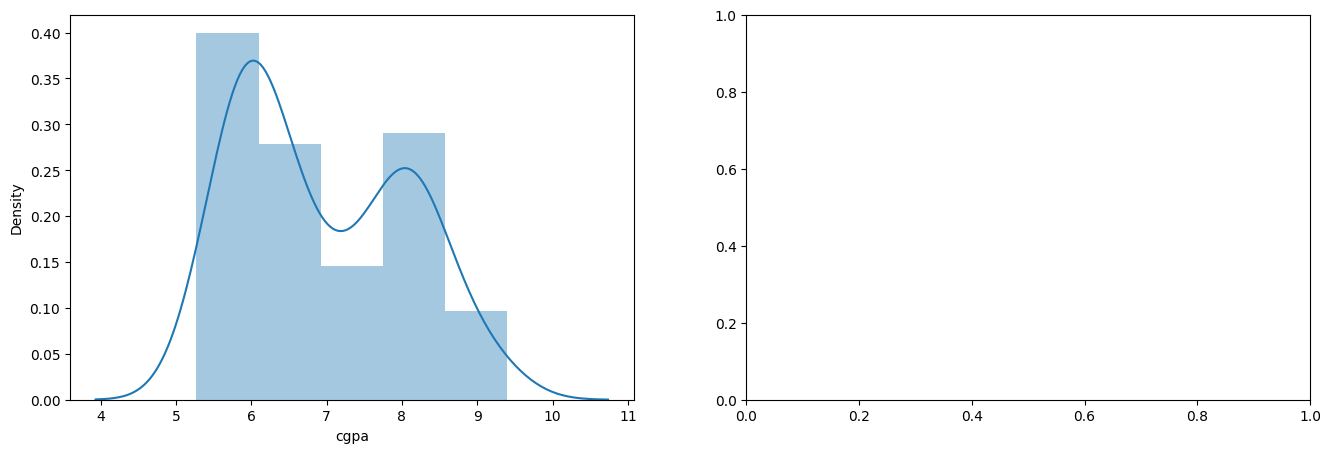

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [7]:
df ['placement_exam_marks'].skew()

KeyError: 'placement_exam_marks'

In [8]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.942200000000001
Std value of cgpa 1.1192002736442004
Min value of cgpa 5.27
Max value of cgpa 9.4


In [9]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 10.299800820932601
Lowest allowed 3.5845991790673994


In [10]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,resume_score,placed
15,8.88,5.93,1
34,8.87,7.19,1
37,9.05,8.21,1
76,9.40,5.50,1
93,9.31,7.39,1


In [11]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [12]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [13]:
df.head()

,cgpa,resume_score,placed,cgpa_zscore
0,8.14,6.52,1,1.070228
1,6.17,5.17,0,-0.689957
2,8.27,8.86,1,1.186383
3,6.88,7.27,1,-0.055575
4,7.52,7.30,1,0.516261


In [14]:

df[df['cgpa_zscore'] > 3]

,cgpa,resume_score,placed,cgpa_zscore


In [15]:

df[df['cgpa_zscore'] < -3]

,cgpa,resume_score,placed,cgpa_zscore


In [16]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,resume_score,placed,cgpa_zscore


In [17]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [18]:
new_df

,cgpa,resume_score,placed,cgpa_zscore
0,8.14,6.52,1,1.070228
1,6.17,5.17,0,-0.689957
2,8.27,8.86,1,1.186383
3,6.88,7.27,1,-0.055575
4,7.52,7.30,1,0.516261
...,...,...,...,...
95,6.33,6.38,0,-0.546998
96,8.23,7.76,1,1.150643
97,6.65,7.78,0,-0.261079
98,8.14,5.63,1,1.070228


In [19]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [20]:
lower_limit

np.float64(3.5845991790673994)

In [21]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)


In [22]:
df.shape

(100, 4)

In [23]:
(1000, 4)

(1000, 4)

In [24]:
df['cgpa'].describe()

count    100.0000
mean       6.9422
std        1.1192
min        5.2700
25%        5.9800
50%        6.6200
75%        8.0450
max        9.4000
Name: cgpa, dtype: float64